In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
depth_values = [1,2,3,5,7,10]
datasets = ["bc",  "hp", "hpimp"]

df = pd.read_csv("./dt_metrics.csv")
df.head()

,dataset,hyperparam,value,kind,accuracy,precision,sensitivity,specificity,f1
0,bc,criterion,entropy,test,0.946903,1.00000,0.869565,1.000000,0.930233
1,bc,criterion,entropy,train,0.978070,1.00000,0.939759,1.000000,0.968944
2,bc,criterion,gini,test,0.938053,0.97561,0.869565,0.985075,0.919540
3,bc,criterion,gini,train,0.969298,1.00000,0.915663,1.000000,0.955975
4,bc,max_depth,10,test,0.964602,0.93750,0.978261,0.955224,0.957447


In [15]:
def get_dataset_name(dataset):
    if dataset == "bc":
        return "Breast Cancer"
    elif dataset == "hp":
        return "Hepatitis"
    else:
        return "Hepatitis (Imputed)"

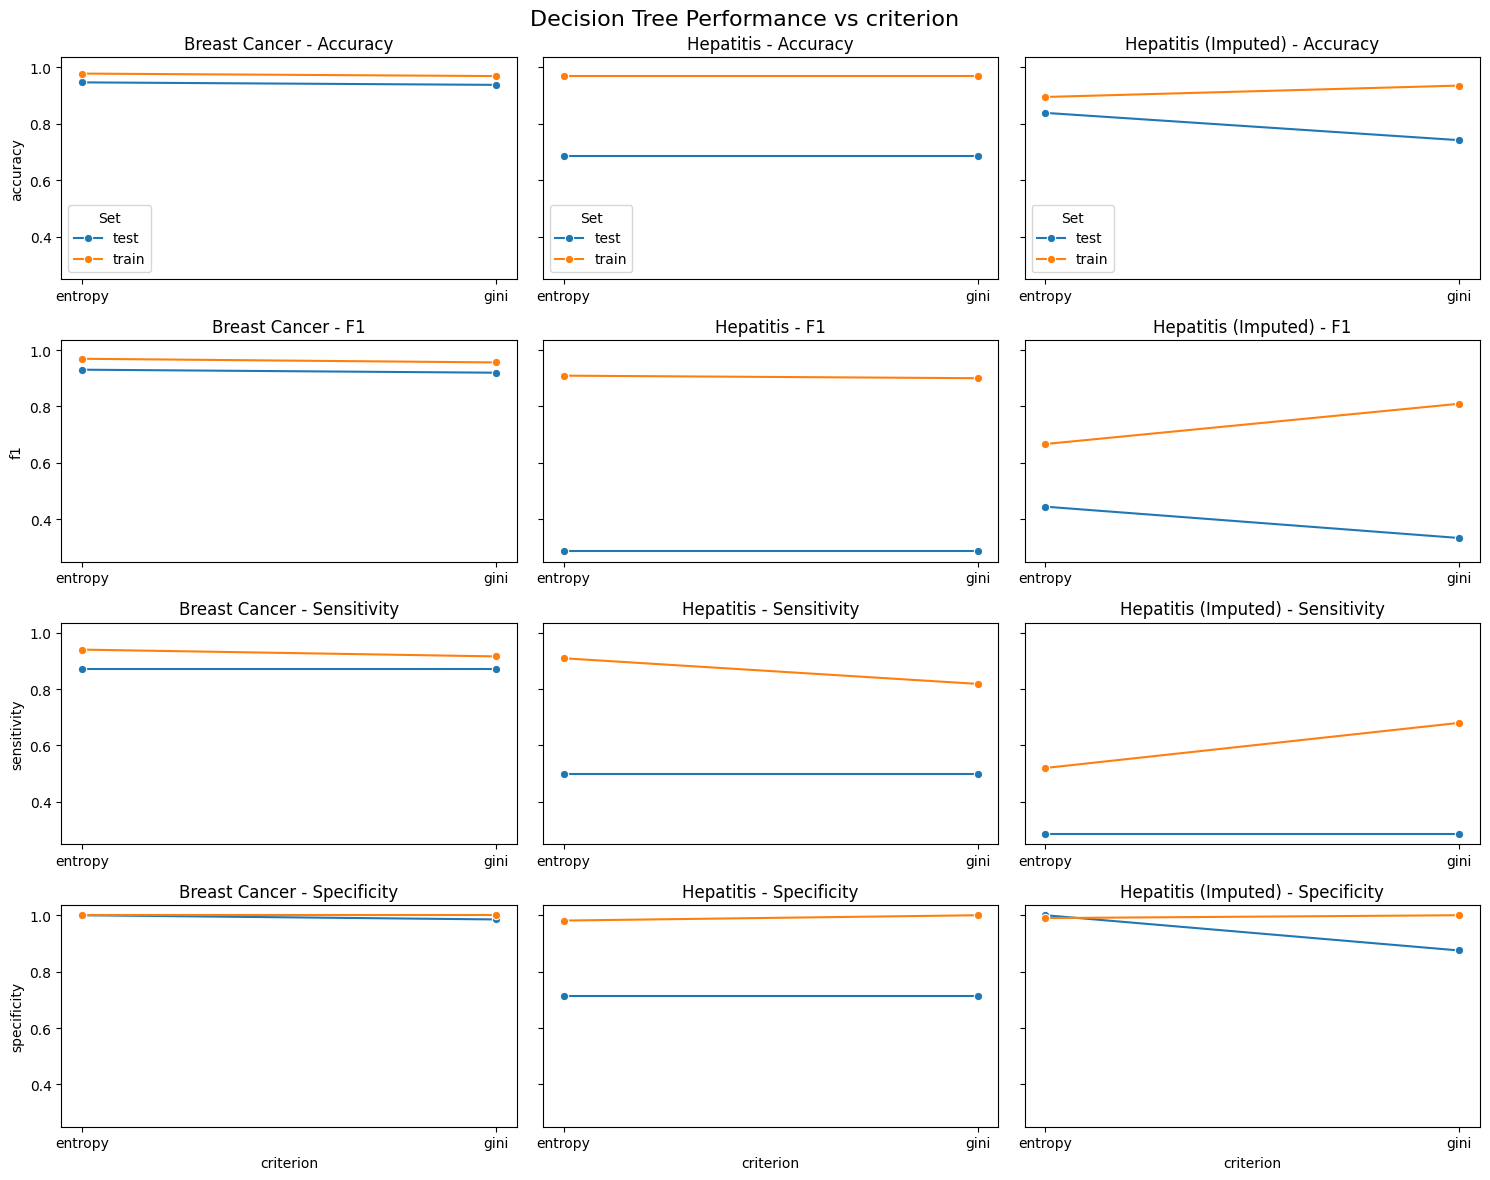

C:\Users\nive0\AppData\Local\Temp\ipykernel_19460\1285983200.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hyper_df["value"] = hyper_df["value"].astype(int)


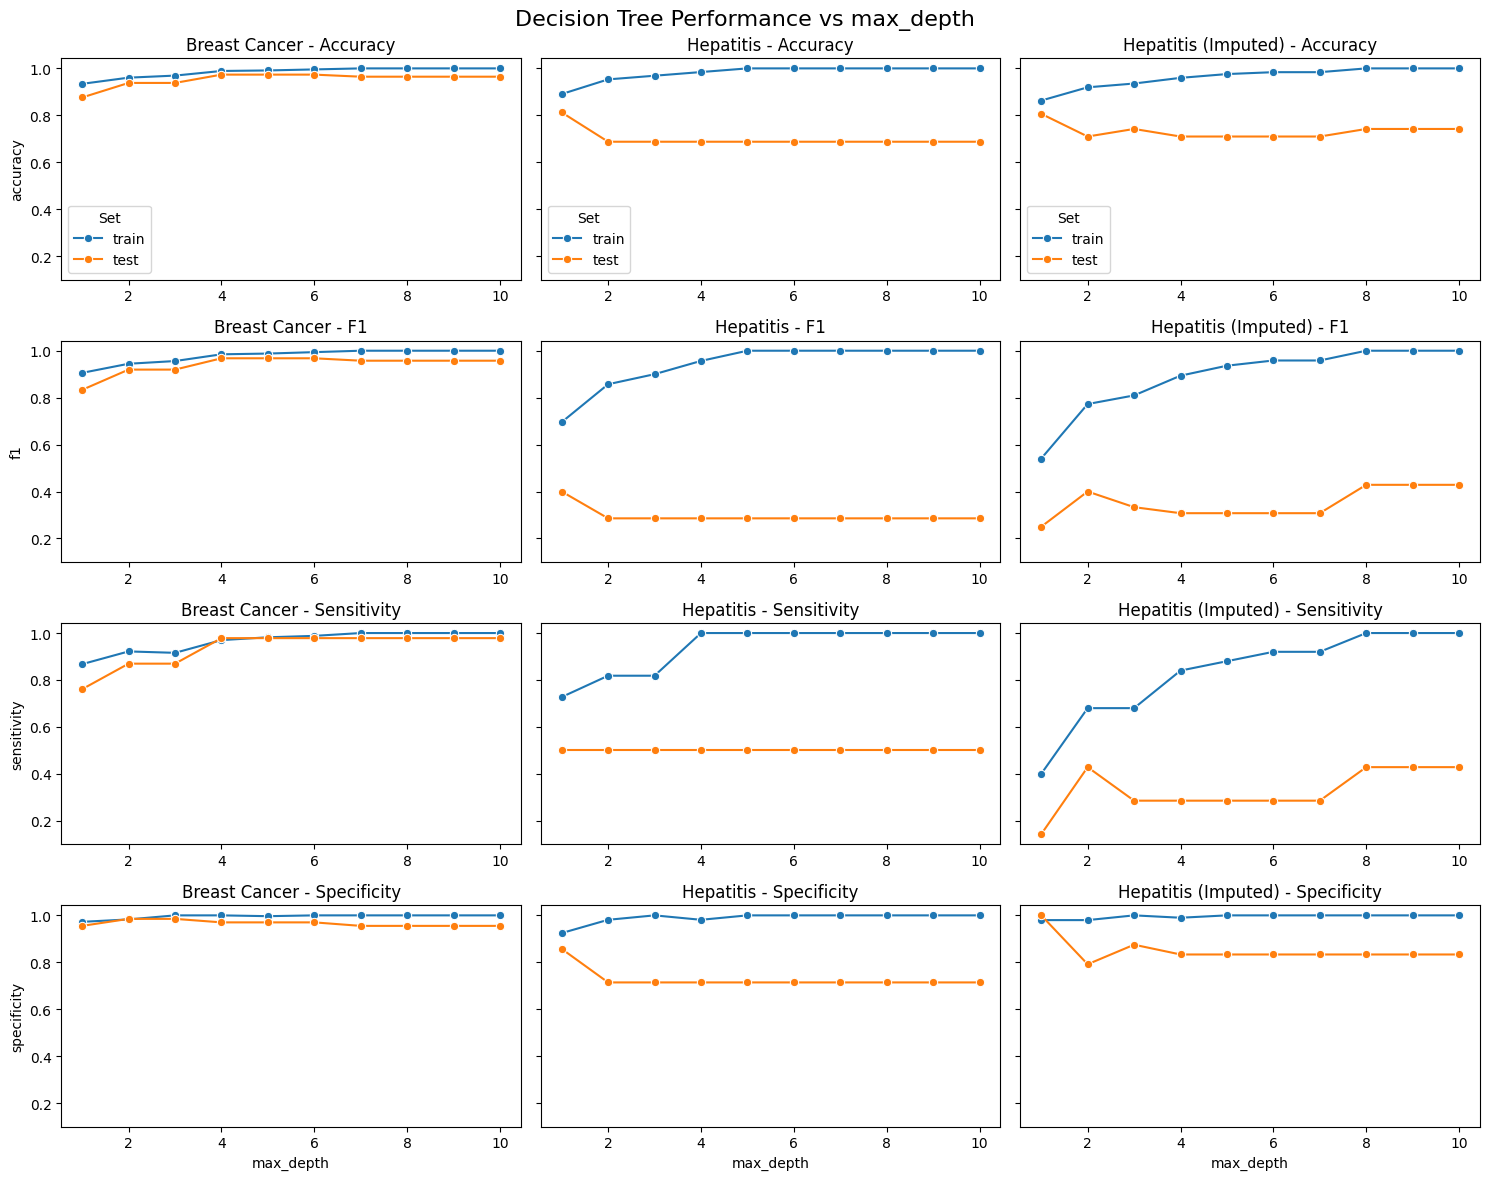

C:\Users\nive0\AppData\Local\Temp\ipykernel_19460\1285983200.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hyper_df["value"] = hyper_df["value"].astype(int)


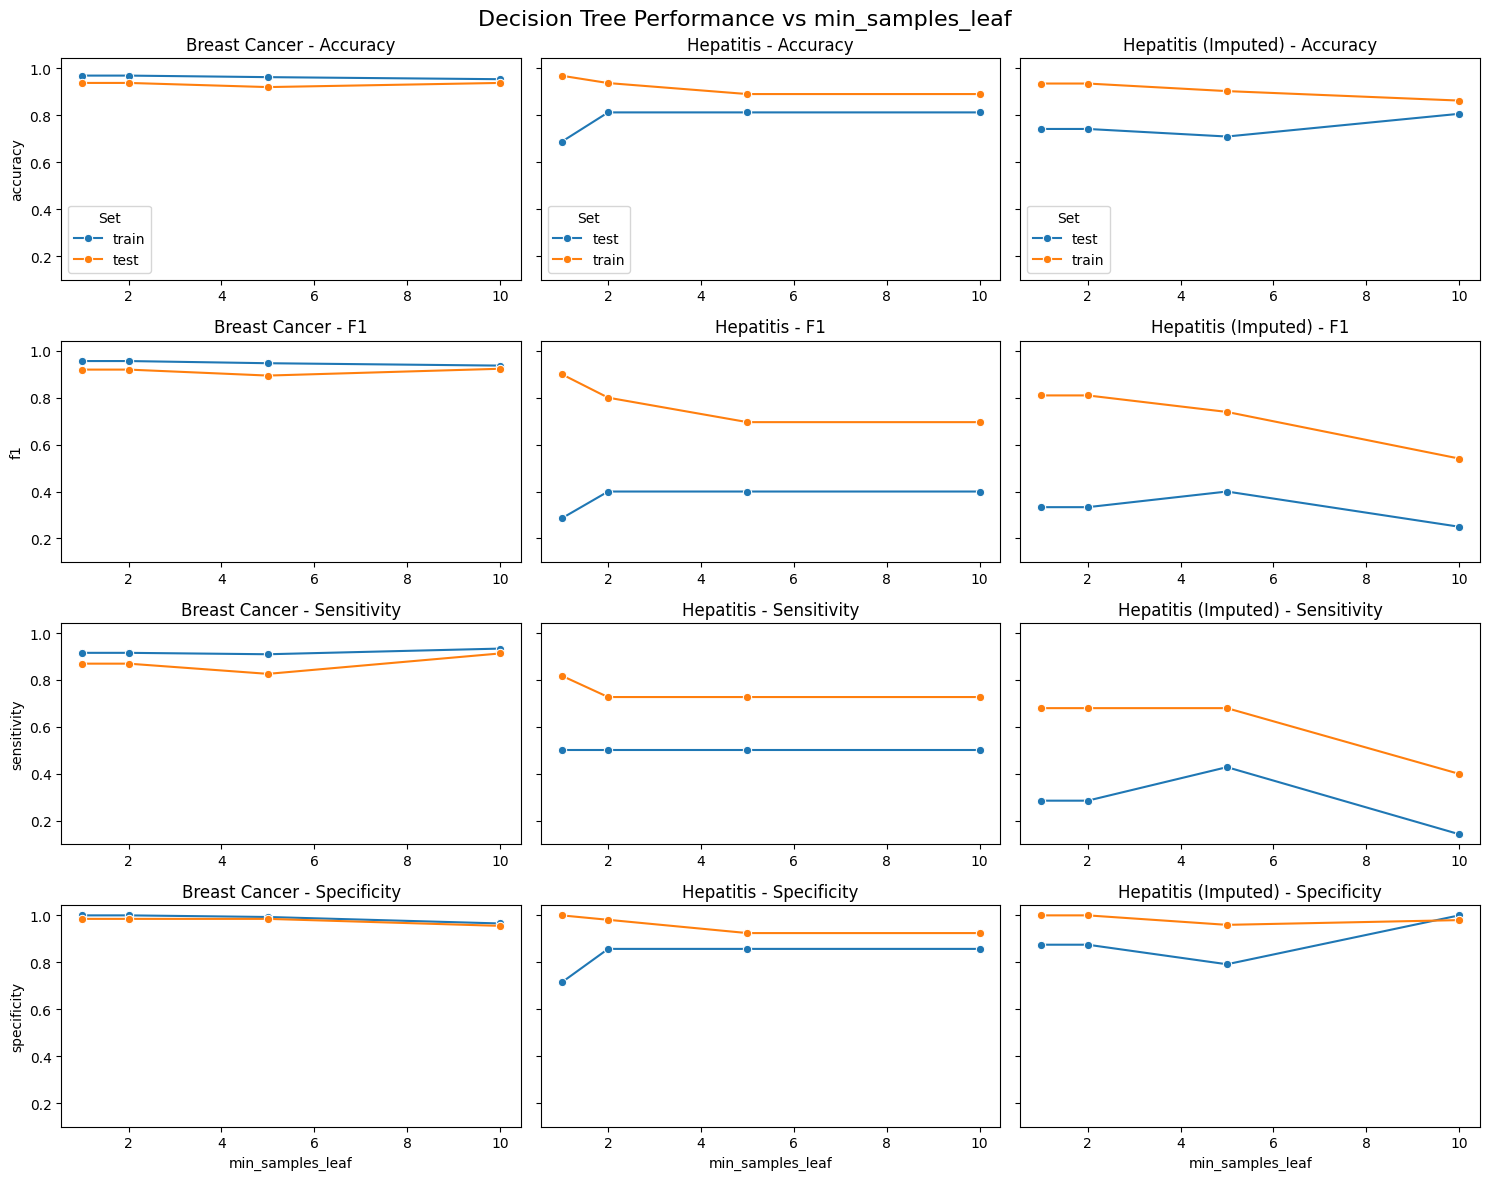

C:\Users\nive0\AppData\Local\Temp\ipykernel_19460\1285983200.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hyper_df["value"] = hyper_df["value"].astype(int)


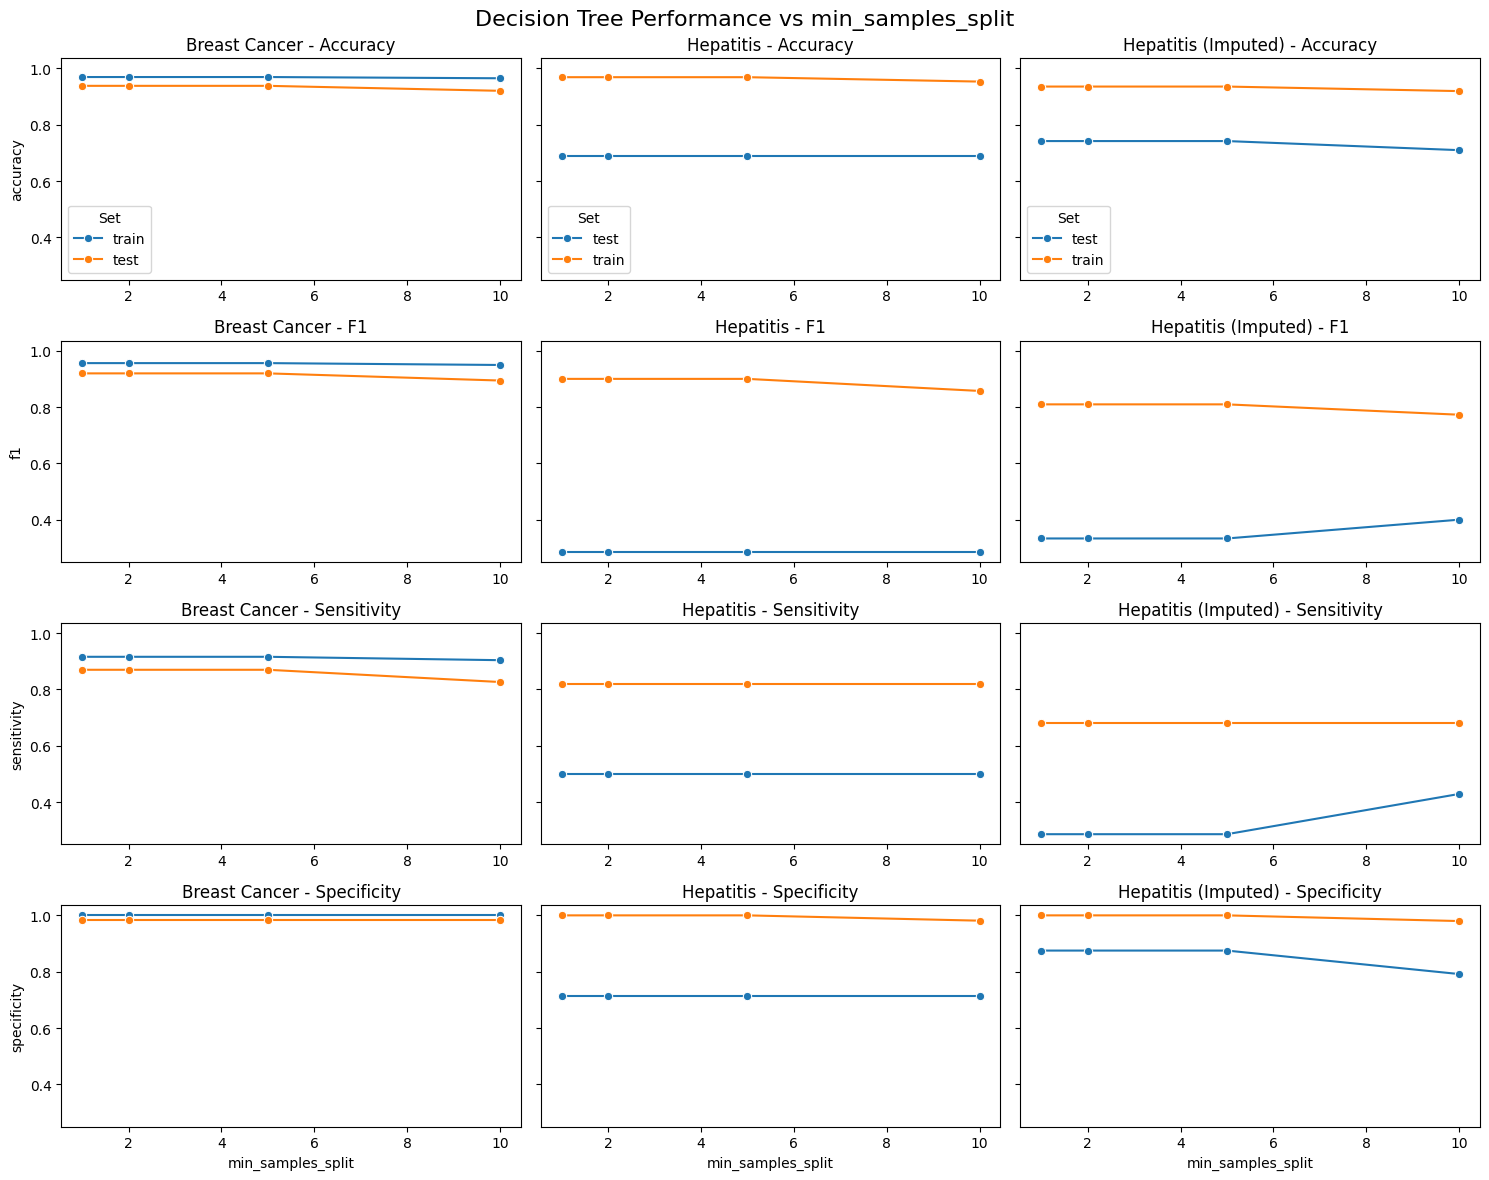

In [28]:
metrics_to_plot = ["accuracy", "f1", "sensitivity", "specificity"]
datasets = ['bc', 'hp', 'hpimp']
hyperparams = df["hyperparam"].unique()

for hyperparam in hyperparams:

    fig, axes = plt.subplots(len(metrics_to_plot), 3, figsize=(15,12), sharex=False, sharey=True)

    hyper_df = df[df["hyperparam"] == hyperparam]
    if hyperparam != 'criterion':
        hyper_df["value"] = hyper_df["value"].astype(int)
        hyper_df = hyper_df.sort_values("value")

    for i, metric in enumerate(metrics_to_plot):
        for j, dataset in enumerate(datasets):

            ax = axes[i, j]

            subset = hyper_df[hyper_df["dataset"] == dataset]
            

            sns.lineplot(
                data=subset,
                x="value",          
                y=metric,
                hue="kind",         
                marker="o",
                ax=ax
            )

            ax.set_title(f"{get_dataset_name(dataset)} - {metric.title()}")

            if i == len(metrics_to_plot)-1:
                ax.set_xlabel(hyperparam)
            else:
                ax.set_xlabel("")

            if j == 0:
                ax.set_ylabel(metric)
            else:
                ax.set_ylabel("")

            if i == 0:
                ax.legend(title="Set")
            else:
                ax.get_legend().remove()

    fig.suptitle(f"Decision Tree Performance vs {hyperparam}", fontsize=16)

    plt.tight_layout()
    plt.show()


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

metrics = ["accuracy", "sensitivity", "specificity", "f1"]

for i, dataset in enumerate(datasets):
    ax = axes[i]
    data = df[df["dataset"] == dataset]

    for metric in metrics:
        ax.plot(data["tree_depth"], data[metric], marker="o", label=metric)

    ax.set_title(get_dataset_name(dataset))
    ax.set_xlabel("Tree Depth")
    ax.set_ylabel("Score")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()